# **VISUALIZATIONS**

In order to see what going on in your data and garner an understanding of wether or not your hypothesis is reasonable, we need to quite literally look at our data. That means we need to learn how to make plots. Fortunately, python has a very well used standard package for making plots: matplotlib. Let's take a look at it [Matplotlib](https://matplotlib.org/).

**TO REMOVE: Sarah I was thinking that you could literally orient students to the website [ie. go through the tabs and show what each one is]. It might seem like a dumb exercise but showing students how to read the devdocs for a well documented package will give them some insight into how to interpret shitty devdocs in more science specific packages.**

**There is a number of semi redundant tabs between Plot Types, User Guide, Tutorial and Examples but I think showing that students can read these to figure out how a package works. I suggest starting with mentioning tabs they are least likely to use [contributions and releases], then navigating to the user guide tab and open the quick start guide because the plot anatomy is thing concept that I think is most important to map for them. You can also introduce the reference page as the resource to turn to if they are messing around with specifics and want to do one very specific step. You can then show the example of investigating an axis object to find the xlim or ylim method as an example.**

## Plot Anatomy

[Plot Anatomy](https://matplotlib.org/stable/_images/anatomy.png), is a means for us to establish a common language to talk about altering aspects of a visualization. We are going to use the matplotlib example to build an understanding of how to communicate about visualizations in a manner that makes it easy to map our conversations to the matplotlib reference manual.

Lets start with going over the items in the first figure of this user guide:

In [2]:
## What is a figure?

# A figure is the ENTIRE visualization. you can think of it as the outermost wrapper that contains all the guts, subplots axes etc.

# Note to sarah this will be empty because there is nothing in it yet.

import matplotlib.pyplot as plt

fig = plt.figure()
fig.show()

<Figure size 640x480 with 0 Axes>

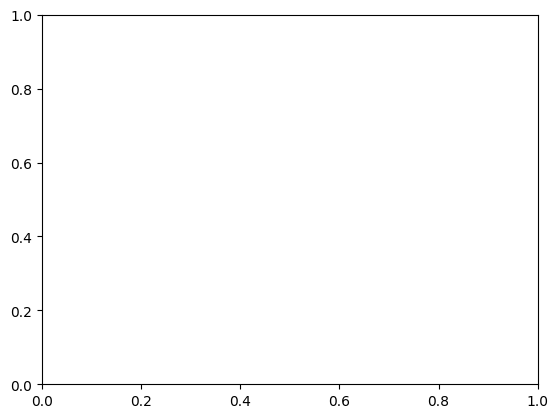

In [3]:
## What is a subplot

# As we go though the different elements of a plot we will take the top-down
# approach talking about each layer as if it was the skin of an orge, therefore
# an onion.

# A subplot is the next layer of a plot. It contains the child Axes and nested
# objects (titles, axes, etc.) that can be used to decribe it. You might find it
# redundant in the case of having a single subplot, but it is an important
# element when you want to have multiple different figures in one visualization.

fig, ax = plt.subplots()
fig.show()

# Lets go to the reference doc and make a figure with 3 subplots in one column.
# Alter the code above to make your new visualization.

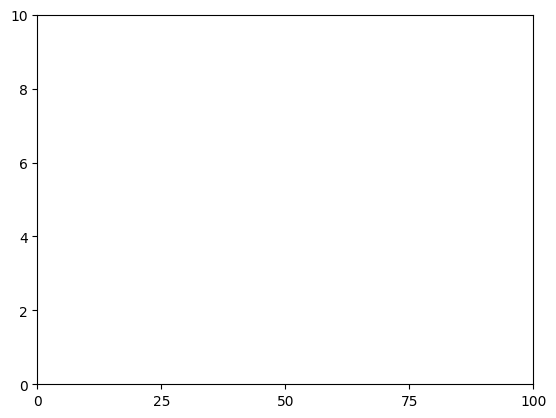

In [12]:
## What are axes?

# An Axes object is a representation of everything that is in a figure. It
# describes the plotting area, axes scale and limit (across 2 or 3 dim) as well
# as any labels and title

# Note it is important to recognize that there is also a seperate axis object
# which controls the scale, limit and tick marks of ONE of the plots axes.

# Let's see this in action

import numpy as np

fig, ax = plt.subplots()
ax.set_xlim(0,100)
ax.set_xticks(np.arange(0, 101, 25))
ax.set_ylim(0,10)
fig.show()

Now that you know how to alter axes, what are other important features of a visualization that you think might be needed?

Can you identify the commands to add those?

**TO REMOVE: Sarah I'm hoping they come up with axes labels, legends, colour. For now just get them to identify things ask them to remember what they found so they can apply them when they have data on the plot**

## Plotting data

Now we are ready to plot some data! The question is what data?

Matplot lib is build to work with numpy arrays primairy but luckily has some capacity to translate dictionary like objects (such as our pandas dataframe) and plot those. Lets load in that data now and make our first plot!

In [25]:
import pandas as pd

file_id =
url =

data = pd.read_csv(url)
data.head().style.hide(axis="index")

Movie,Studio,Year,Tomatometer,Popcorn meter,Enjoyment,Fun,Silly,NChris
Iron Man,1,2008,94,91,7.456790,5.587500,2.790123,nan
Punisher: War Zone,1,2008,29,42,4.785714,4.071429,4.785714,nan
The Dark Knight,2,2008,94,94,7.455696,4.721519,2.417722,nan
The Incredible Hulk,1,2008,68,69,5.444444,4.092593,4.537037,nan
Watchmen,2,2009,64,71,6.163265,4.170213,3.469388,nan


Now that we're looking at the data, I've always wondered, did professional movie critics ever get their ratings right? Are well rated movies actually enjoyed by the audience?

Let's think about how we can plot this

**TO REMOVE: Sarah this is where I would start a discussion about what it means to represent data on plots. I would push them to think about how a series, colour, axis, subplots, marker types could be used to represent different variables of interest in an experiment**



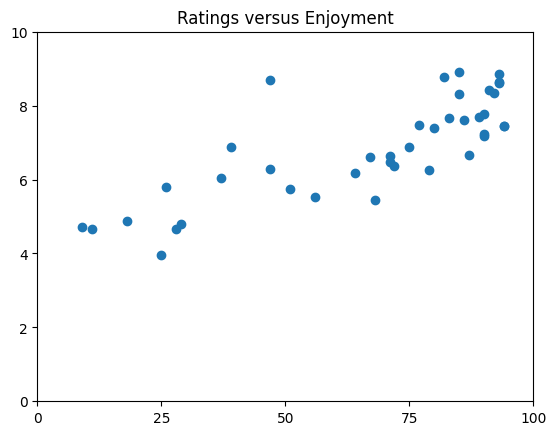

In [30]:
# Let's make a plot of tomatometer vs enjoyment

#SARAH: I am leaving some commented lines here to show you how to add labels and
# whatnot so you don't have to. Remove them before starting the tutorial and
# get the students to come up with stuff :)

fig, ax = plt.subplots()
ax.scatter('Tomatometer', 'Enjoyment', data=data)
ax.set_xlim(0,100)
ax.set_xticks(np.arange(0, 101, 25))
ax.set_ylim(0,10)
#ax.set_xlabel('Tomatometer [0-100]')
#ax.set_ylabel('Enjoyment [0-10]')
#ax.set_title('Ratings versus Enjoyment')
fig.show()

Well the data's on there but what are we looking at?

How would you make this plot better?

## Adding more variables

Now we see that higher rating do reflect more enjoyment is that any better than the ratings from an average Joe?

How might you integrate "Popcornmeter" onto this plot?

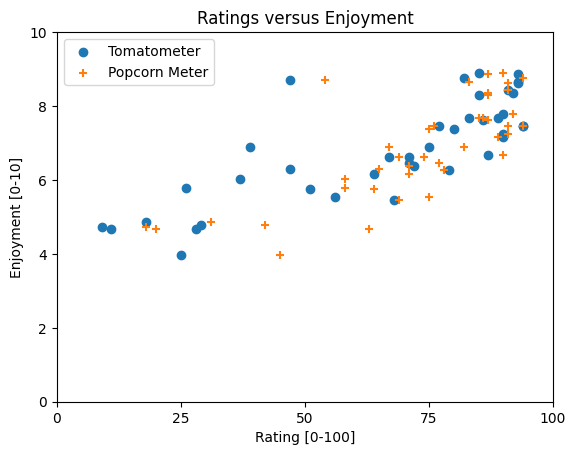

In [36]:
#Same dealeo here sarah I am trying to predict their responses and give you some plotting options

fig, ax = plt.subplots()
ax.scatter('Tomatometer', 'Enjoyment', data=data)
#ax.scatter('Popcorn meter', 'Enjoyment', data=data, c='red') #colour
#ax.scatter('Popcorn meter', 'Enjoyment', data=data, marker = '+') #colour
ax.set_xlim(0,100)
ax.set_xticks(np.arange(0, 101, 25))
ax.set_ylim(0,10)
ax.set_xlabel('Rating [0-100]')
ax.set_ylabel('Enjoyment [0-10]')
ax.set_title('Ratings versus Enjoyment')
#ax.legend(['Tomatometer','Popcorn Meter'])
fig.show()

Do you think the answer is clear here?

Is there another plot that might do a better job of separating the difference between each type of reviewer?

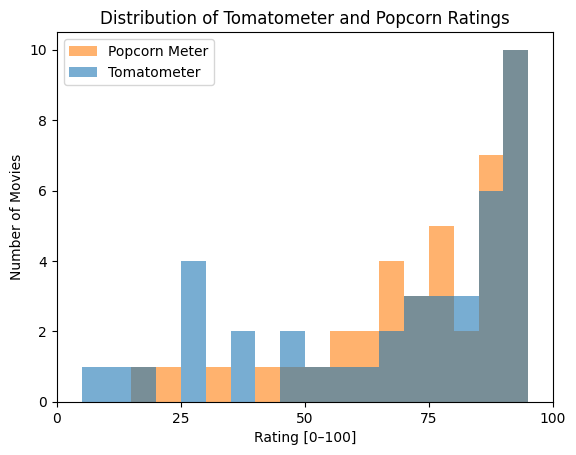

In [64]:
# Let's try using a histogram

fig, ax = plt.subplots()

bins = np.arange(0, 105, 5)

ax.hist(data['Popcorn meter'], bins=bins, alpha=0.6, label='Popcorn Meter',
        color='tab:orange')

ax.hist(data['Tomatometer'], bins=bins, alpha=0.6, label='Tomatometer',
        color='tab:blue')

ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 25))
ax.set_xlabel('Rating [0–100]')
ax.set_ylabel('Number of Movies')
ax.set_title('Distribution of Tomatometer and Popcorn Ratings')
ax.legend()
fig.show()

What can you tell from these histograms? Does this plot answer our question?

**TO REMOVE: This is a bit of a misdirection exercise, hopefully the students recognize that this plot doesn't tell up about the y variable of interest [Enjoyment]**

/tmp/ipykernel_7466/3276549704.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap = (data.pivot_table(index="Popcorn_bin", columns="Tomato_bin",


0.7643667010320911
0.8039155202968798


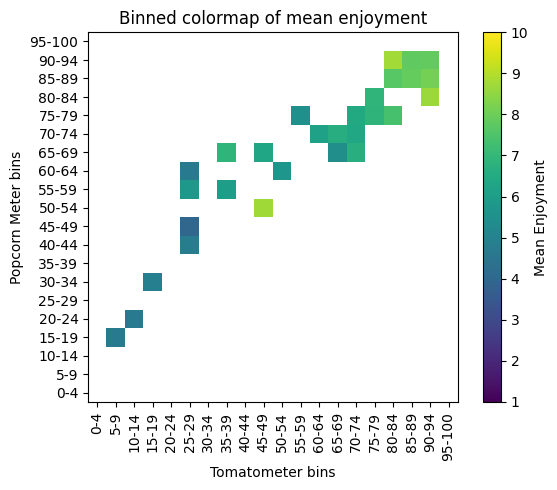

In [70]:
# Let's try another style of plot that better captures the variables of interest:
# tomatometer, popcorn meter and enjoyment

#create some numerical and string bins labels
labels = np.arange(20)
bin_labels = [f"{i*5}-{i*5+4}" for i in range(19)] + ["95-100"]

#add numberical bins to dataframe to facilitate plotting
data["Tomato_bin"] = pd.cut(data["Tomatometer"], bins=bins, labels=labels,
                            include_lowest=True, right=False)

data["Popcorn_bin"] = pd.cut(data["Popcorn meter"], bins=bins, labels=labels,
                             include_lowest=True, right=False)

#create heatmap to plot
heatmap = (data.pivot_table(index="Popcorn_bin", columns="Tomato_bin",
                            values="Enjoyment", aggfunc="mean")
                            .reindex(index=labels, columns=labels))

#plot
fig, ax = plt.subplots()

im = plt.imshow(heatmap, origin="lower", interpolation="nearest",
                cmap=plt.cm.viridis, vmin=1, vmax=10)

ax.set_xticks(np.arange(20), bin_labels, rotation=90)
ax.set_yticks(np.arange(20), bin_labels)

ax.set_xlabel("Tomatometer bins")
ax.set_ylabel("Popcorn Meter bins")
ax.set_title("Binned colormap of mean enjoyment")

cbar = plt.colorbar(im)
cbar.set_label("Mean Enjoyment")

fig.show()


Now we can better see this relationship! or more specifically how closely both types of reviewers rate movies. Both measures seem to track enjoyment but the average Joes seem to be more generous than the professional movie critis.

However, to answer our question on wether one type of review is more accurate than the other we will need the power of statistics!